## A06b

In [40]:
# import pandas --- spreadsheet library
import pandas as pd

import numpy as np

# import matplotlib --- plotting library
import matplotlib.pyplot as plt

from plotting import make_overview, compare
from myio import read_in_weather_data

In [41]:
%matplotlib inline
%pwd

'C:\\Users\\acouedel2\\Dropbox\\GYGA Oil Palm Indonesia\\PALMSIM\\calibration'

In [56]:
import os

fdir = '../../Data/Calibration Data/Agrifood/Clean data'

fpath = os.path.join(fdir,'Yield/testAntoine.csv')

dfo = pd.read_csv(fpath)
dfo = dfo.set_index(pd.to_datetime(dfo['Month']))
dfo = dfo.dropna(how='all')

fpath = os.path.join(fdir, 'Weather/A06b.csv')

dfw = read_in_weather_data(fpath)

In [57]:
dfo = dfo.dropna(how='all')

In [59]:
import sys
sys.path.append('../PALMSIM')
sys.path.append('..')
from PALMSIM import PalmField
from PALMSIM import Indeterminate
from PALMSIM import Fronds

# 1. Initialize the model
dt = 10

# different variety!
Fronds.parameters['initiation_rate_a']['value'] = 22 # 25 -> 22 fronds/year as asymptotic value

p = PalmField(year_of_planting=1991, month_of_planting=1, dt=dt)
p.soil.parameters['water_holding_capacity']['value'] = 400

# 2. Couple the solar radiation data:
dfw = dfw.resample('D').pad()
dfw = dfw.rolling(dt, center=True).mean()
dfw = dfw.fillna(method='pad')

p.weather.radiation_series = dfw['Solar']
p.weather.rainfall_series = dfw['Precip']
p.weather.humidity_series = dfw['RelHum']

nyears = 30

duration = nyears*365

df = p.run(duration=duration)

Saving at: plots\testAntoine.png


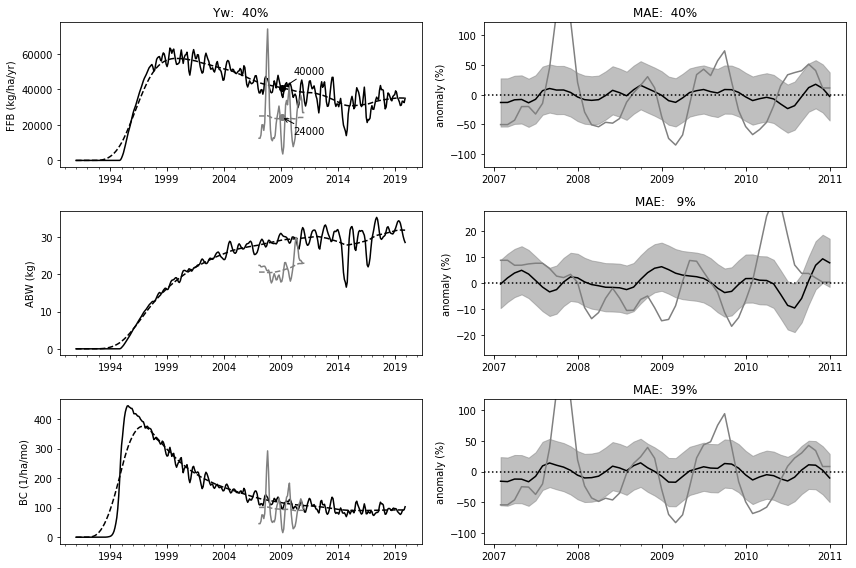

In [60]:
sname = 'testAntoine'

make_overview(df, dfo, sname, window=3)

Saving at: plots\A06b.png


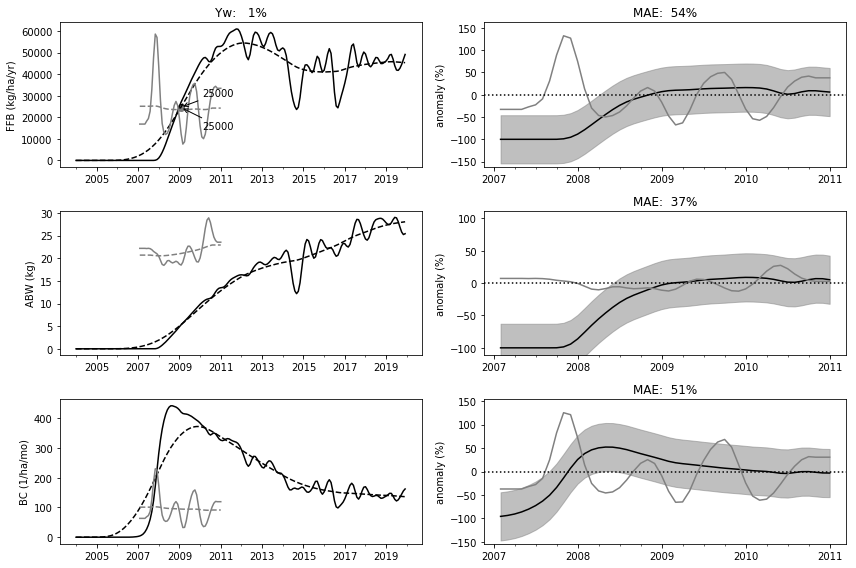

In [35]:
make_overview(df, dfo, sname, window=6)

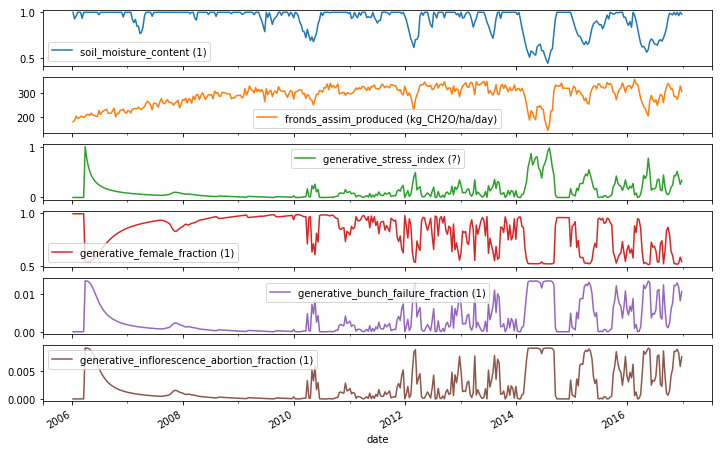

In [36]:
cs = ['soil_moisture_content (1)',
      'fronds_assim_produced (kg_CH2O/ha/day)',
      'generative_stress_index (?)',
      'generative_female_fraction (1)',
      'generative_bunch_failure_fraction (1)',
     'generative_inflorescence_abortion_fraction (1)']

df.loc['2006':'2016',cs].plot(subplots=True, figsize=(12,8));